# Importando classes

In [1]:
# Torch
import torch
import torch.nn as nn
import torchvision.transforms as transforms
import torchvision
import torchvision.datasets as datasets
import torch.optim as optim
from torch.utils.data import random_split, Subset

# Módulos Próprios
from utils.devFunctions import Imshow

# Numpy
import numpy as np

# PIL
from PIL import Image

# Definições

In [2]:
# Device
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Variáveis de Ambiente
BATCH_SIZE = 32
EPOCH = 8
LEARNING_RATE = 1e-2
DATA_PATH = "/media/kaua-matheus/HD320/Data/Agroscope/Especialista_Tratado/Soybean_Tratado"

print(f"Dispositivo Usado: {"GPU" if DEVICE.type == "cuda" else "CPU"}")

Dispositivo Usado: GPU


## Transform

In [3]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomRotation(10),
    transforms.RandomHorizontalFlip(p=.5),
    transforms.RandomVerticalFlip(p=.2),
    transforms.CenterCrop((192, 192)),

    transforms.RandomApply([
        transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 2.0))
    ], p=0.3),

    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
])

## Dataset Principal

In [4]:
full_dataset = datasets.ImageFolder(root=DATA_PATH, transform=transform)

In [5]:
class_indices = {0: [], 1: [], 2: []}

for idx, (_, label) in enumerate(full_dataset.imgs):
    class_indices[label].append(idx)


low = None
for _, imgs in class_indices.items():
    if low == None:
        low = len(imgs)
    else:
        if low >= len(imgs):
            low = len(imgs)
        else:
            continue

In [6]:
import random

balanced_indices = []

for class_label, indices in class_indices.items():
    if len(indices) > low:
        random.shuffle(indices)
        selected_indices = indices[:low]
    else:
        selected_indices = indices

    balanced_indices.extend(selected_indices)
    print(f"Class {class_label}: {len(selected_indices)}")

random.shuffle(balanced_indices)
balanced_dataset = Subset(full_dataset, balanced_indices)

Class 0: 1081
Class 1: 1081
Class 2: 1081


In [7]:
train_size = int(0.8 * len(balanced_dataset))
test_size = len(balanced_dataset) - train_size

In [8]:
print(f"All Dataset: {len(balanced_dataset)}")
print(f"Train (80%): {train_size}")
print(f"Test (20%): {test_size}")

All Dataset: 3243
Train (80%): 2594
Test (20%): 649


In [9]:
train_dataset, test_dataset = random_split(balanced_dataset, [train_size, test_size])

In [10]:
# Podemos paralelizar usando persistent_workers=True

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=BATCH_SIZE, num_workers=4, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=BATCH_SIZE, num_workers=4, shuffle=True)

### Mostrando as imagens do trainset

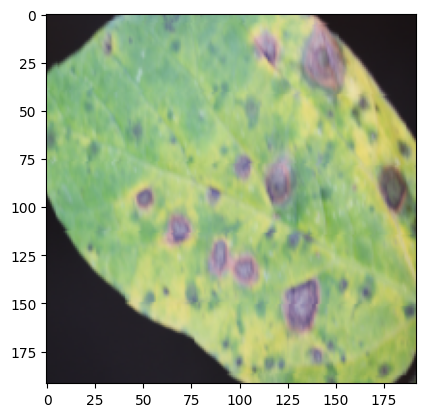

In [11]:
image = Image.open(balanced_dataset.dataset.imgs[np.random.randint(0, len(balanced_dataset.dataset.imgs)-1)][0])
image_tensor = transform(image)

Imshow(torchvision.utils.make_grid(image_tensor.unsqueeze(0))) # type: ignore

In [12]:
from utils.models import NeuralNetworkUpper

# Definindo o otimizador e a função de perda

In [13]:
Net = NeuralNetworkUpper().to(DEVICE)

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(Net.parameters(), lr=LEARNING_RATE, momentum=0.9)

# Treinando o modelo

In [14]:
for epoch in range(EPOCH):

    running_loss = 0.0

    for images, labels in train_loader:

        """
            Nesse caso, images é a representação em matriz da imagem.
            E labels é a representação de cada camada da CNN, se ela ativou ou não.
        """

        # Adquirindo entradas, "data" é uma lista [inputs, labels]
        images, labels = images.to(DEVICE), labels.to(DEVICE)

        # zerando os parâmetros dos gradientes
        optimizer.zero_grad()

        outputs = Net(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        
    print(f'[{epoch + 1}] loss: {running_loss / 2000:.3f}')

print("Treinamento concluído!")

[1] loss: 0.033
[2] loss: 0.030
[3] loss: 0.026
[4] loss: 0.024
[5] loss: 0.018
[6] loss: 0.016
[7] loss: 0.014
[8] loss: 0.013
Treinamento concluído!


# Avaliando o modelo

In [15]:
# Avaliação de resultados
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, roc_auc_score
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

In [16]:
Net.eval()
all_preds = []
all_labels = []
all_probs = []

with torch.no_grad():  # Desativa o cálculo de gradientes para economizar memória
    for images, labels in test_loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        outputs = Net(images)

        probabilities = torch.softmax(outputs, dim=1)
        all_probs.extend(probabilities.cpu().numpy())

        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())


accuracy = accuracy_score(all_labels, all_preds)
print(f"Accuracy of the model on the test set: {accuracy * 100:.2f}%")

Accuracy of the model on the test set: 33.90%


In [40]:
import datetime as dt
t = dt.datetime.now()

In [41]:
# Definição de Metadados
CLASSES = full_dataset.classes
NOW = "{}-{}-{} {}:{}:{}".format(t.day, t.month, t.year, t.hour, t.minute, t.second)

In [22]:
torch.save({
    "model_state_dict": Net.state_dict(),
    "class_names": CLASSES,
    "num_classes": len(CLASSES),
    "model_info": {
        "version": "1.0",
        "training_date": NOW,
        "accuracy": accuracy
    }
    }, "./Models/Test/soybeanAI.pth")

## Testes Extras

### Confusion Matrix
A matrix de confusão mostra onde o modelo mais se confunde, ou seja, quais classes mais se "parecem" com outras, segundo o modelo.

Na nossa análise, podemos reparar que o modelo mais confunde a ferrugem comum com os outros (saudável e polissora), sendo assim, mais padrões necessitam ser identificados, principalmente na ferrugem comum para melhorar a identificação.\
De todos os erros (27 ao todo), 26 foram na ferrugem comum, confundindo-a com saudável ou polissora.

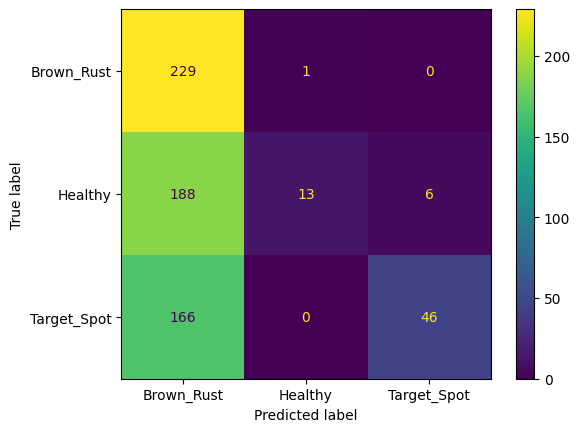

In [42]:
confusion_matrix_eval = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix_eval, display_labels=full_dataset.classes)
disp.plot()
plt.show()

### Precision, Recall e F1-Score
Necessário para identificar ponderação nas predições. Em alguns datasets, a quantidade de registros de uma classe pode ser maior do que outras, isso significa um desbalanço nos dados, portanto, uma ponderação de acerto deve ser aplicada.\
Por conta disso, F1-Score avalia a média harmônica da precisão e do recall, visando encontrar um indicador de bom equilibrio entre corretamente positivos e todos os positivos.\
O valor de F1 varia de 0 e 1, onde 1 é o melhor.

In [19]:
f1 = f1_score(all_labels, all_preds, average=None)
f1

array([0.33333333, 0.        , 0.        ])

### Roc e Auc

In [20]:
all_probs = np.array(all_probs)

In [21]:
roc_auc = roc_auc_score(all_labels, all_probs, multi_class="ovo")
print(f"Roc-Auc Score: {roc_auc:.4f}")

Roc-Auc Score: 0.7921


In [22]:
roc_auc_macro = roc_auc_score(all_labels, all_probs, multi_class="ovr")
print(f"Roc-Auc Macro: {roc_auc_macro:.4f}")

Roc-Auc Macro: 0.7811


# Salvando Modelo

In [23]:
torch.save(Net.state_dict(), "./Models/New Models/Expert/SoybeanAI_v1.pth")

# Carregando Modelo

In [ ]:
Net = NeuralNetworkUpper().to(DEVICE)
Net.load_state_dict(torch.load("./Models/New Models/Expert/SoybeanAI_v1.pth"))
Net.eval()

# Testes Extras
Os testes extras visam identificar se o modelo de fato é capaz de generalizar e identificar padrões, mesmo em imagens cheias de ruído e defeitos.

In [24]:
import cv2

In [25]:
sobel_transform = transforms.Lambda(
    lambda img: Image.fromarray(
        cv2.convertScaleAbs(
            np.hypot(
                cv2.Sobel(np.array(img), cv2.CV_64F, 1, 0, ksize=3),
                cv2.Sobel(np.array(img), cv2.CV_64F, 0, 1, ksize=3)
            )
        )
    )
)

In [26]:
jitter = transforms.ColorJitter(brightness=.5, hue=.3)

In [ ]:
test_root = "/media/kaua-matheus/HD320/Data/Agroscope/Teste_Especialista/Soybean"

transform_high = transforms.Compose([
    transforms.Resize((198, 198)),
    #transforms.RandomRotation(2),
    transforms.RandomHorizontalFlip(),
    transforms.CenterCrop((192, 192)),

    jitter,
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)), # Normalizando imagem para apenas um canal ao invés de 3 -> (0.5, 0.5, 0.5), (0.5, 0.5, 0.5)
])

In [ ]:
test_base = datasets.ImageFolder(root=test_root, transform=transform)
test_high = datasets.ImageFolder(root=test_root, transform=transform_high)

In [ ]:
image = Image.open(test_base.imgs[np.random.randint(0, len(test_base.imgs)-1)][0])
image_tensor = transform(image)

Imshow(torchvision.utils.make_grid(image_tensor.unsqueeze(0)), "Default") # type: ignore

In [ ]:
image = Image.open(test_high.imgs[np.random.randint(0, len(test_high.imgs)-1)][0])
image_tensor = transform_high(image)

Imshow(torchvision.utils.make_grid(image_tensor.unsqueeze(0)), "Higher Filters") # type: ignore

In [ ]:
train_loader_base = torch.utils.data.DataLoader(test_base, batch_size=BATCH_SIZE, num_workers=4, shuffle=True)
train_loader_high = torch.utils.data.DataLoader(test_high, batch_size=BATCH_SIZE, num_workers=4, shuffle=True)

In [ ]:
preds_base = list()
preds_high = list()

labels_base = list()
labels_high = list()

probs_base = list()
probs_high = list()

In [ ]:
with torch.no_grad():
    for images, labels in train_loader_base:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        outputs = Net(images)

        probabilities = torch.softmax(outputs, dim=1)
        probs_base.extend(probabilities.cpu().numpy())

        _, predicted = torch.max(outputs, 1)
        preds_base.extend(predicted.cpu().numpy())
        labels_base.extend(labels.cpu().numpy())

accuracy = accuracy_score(labels_base, preds_base)
print(f"Accuracy of the model on the test set: {accuracy * 100:.2f}%")

In [ ]:
with torch.no_grad():
    for images, labels in train_loader_high:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        outputs = Net(images)

        probabilities = torch.softmax(outputs, dim=1)
        probs_high.extend(probabilities.cpu().numpy())

        _, predicted = torch.max(outputs, 1)
        preds_high.extend(predicted.cpu().numpy())
        labels_high.extend(labels.cpu().numpy())

accuracy = accuracy_score(labels_high, preds_high)
print(f"Accuracy of the model on the test set: {accuracy * 100:.2f}%")